In [ ]:
import numpy as np
from q_learning import QLearningAgent, softmax

In [4]:
def run_simulation(alpha_true, beta_true, num_trials):
    """
    実際にエージェントを走らせ、データを生成させるための関数
    """
    reward_probabilities = [0.7, 0.3]   # 報酬の確率分布

    # インスタンス化
    agent = QLearningAgent(alpha=alpha_true, beta=beta_true)

    # 行動と報酬の履歴を保存するためのリストを用意
    history_actions = []
    history_rewards = []

    for t in range(num_trials):
        action = agent.choose_action()

        reward = 1 if np.random.rand() < reward_probabilities[action] else 0

        agent.update_q_value(action, reward)

        history_actions.append(action)
        history_rewards.append(reward)
    
    return history_actions, history_rewards

In [5]:
def calculate_log_likelihood(alpha, beta, history_actions, history_rewards):
    """
    仮説のパラメータが観測データにどれくらい当てはまるのかを計算する
    """
    # 1. 評価したい仮説のパラメータでエージェントをインスタンス化する
    agent = QLearningAgent(alpha=alpha, beta=beta)
    
    log_likelihood = 0.0    # 対数尤度の初期値

    # 2. 観測されたデータを1試行目から順番になぞっていく
    for action, reward in zip(history_actions, history_rewards):
        probabilities = softmax(agent.q_values, agent.beta)

        # 実際にデータ上で選ばれていた行動（action）が選ばれる確率を取り出す
        prob_of_chosen_action = probabilities[action]

        # 確率の対数をとって足し合わせる（対数尤度）
        log_likelihood += np.log(prob_of_chosen_action + 1e-8)

        # 価値更新
        # 実際にrewardを使って価値を更新する
        agent.update_q_value(action, reward)
    
    return log_likelihood

In [6]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "MS Gothic"

def visualize_likelihood_surface(num_trials):
    """
    指定した試行数でデータを生成し、尤度の分布を描画する
    """
    # 1. 真のパラメータ（本来のエージェントの個性）を設定してデータを生成
    true_alpha = 0.3
    true_beta = 2.0
    print(f"--- 試行数 {num_trials} 回でシミュレーション開始")
    actions, rewards = run_simulation(true_alpha, true_beta, num_trials)

    # 2. 探査するパラメータの範囲を設定
    # alphaは0.01~0.99, betaは0.1~5.0の間で、それぞれ50分割して調べる
    alpha_candidates = np.linspace(0.01, 0.99, 50)
    beta_candidates = np.linspace(0.1, 5.0, 50)

    # 尤度を保存するための空の地図（二次元配列）を用意
    likelihoods = np.zeros((len(alpha_candidates), len(beta_candidates)))

    # 3. 総当たり（グリッドサーチ）で全ての組み合わせの尤度を計算
    for i, a in enumerate(alpha_candidates):    # for i, a in enumerate(list)により、listのインデックスを i 、要素を a に代入することで繰り返し処理を行う
        for j, b in enumerate(beta_candidates):
            # 先ほど作った関数で尤度を計算
            log_likelihood = calculate_log_likelihood(a, b, actions, rewards)
            likelihoods[i, j] = log_likelihood
    
    # 4. 結果をヒートマップとして描画
    plt.figure(figsize=(8, 6))
    # 最も当てはまりが良い（尤度が高い）場所が明るい色になる
    plt.imshow(likelihoods, extent=[0.1, 5.0, 0.01, 0.99], origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar(label='Log Likelihood（当てはまりの良さ）')

    # 真のパラメータの位置に赤い星マークを付ける
    plt.plot(true_beta, true_alpha, 'r*', markersize=15, label='True Parameter')

    plt.xlabel('Beta（逆温度）')
    plt.ylabel('Alpha（学習率）')
    plt.title(f'Likelihood Surface (Trials: {num_trials})')
    plt.legend()
    plt.show

--- 試行数 500 回でシミュレーション開始
--- 試行数 20 回でシミュレーション開始


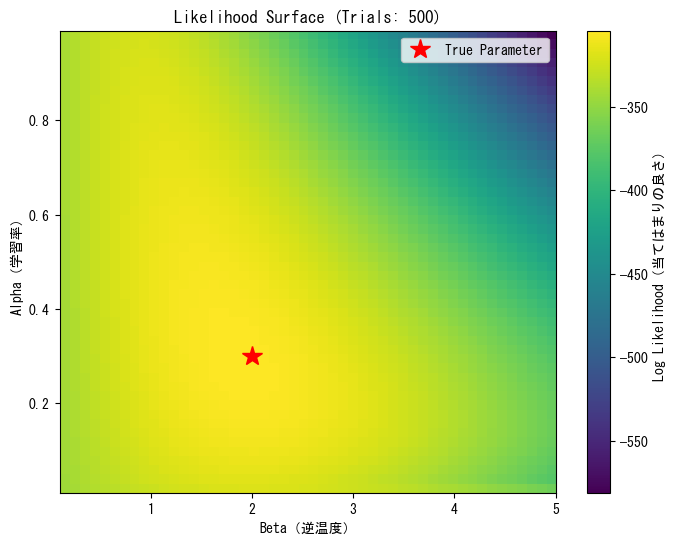

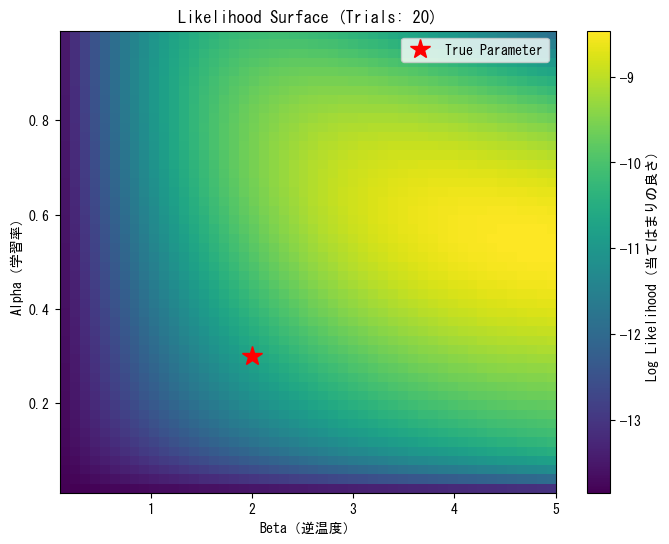

In [7]:
# 実験開始！

# パターンA：試行数が十分にある（信頼できるデータ）場合
visualize_likelihood_surface(num_trials=500)

# パターンB：試行数が少なく、ノイズに弱い場合
visualize_likelihood_surface(num_trials=20)